# Практическое задание: Классификация временных рядов (Time Series Classification)

**Цель обучения:**
Познакомиться с основными парадигмами классификации временных рядов (dictionary-based, shapelet-based, feature-based) и базовыми принципами работы с нейросетевыми архитектурами (1D-CNN) для временных рядов. Научиться применять продвинутые методы извлечения признаков и анализировать результаты их работы.

---

## **Задание №1: Теоретические вопросы**
Ответьте на следующие вопросы кратко (2-3 предложения):

1. В чём принципиальная разница между методами SAX (Symbolic Aggregate approXimation) и SFA (Symbolic Fourier Approximation)? Какой из них лучше справляется с зашумленными данными и почему?
2. Как алгоритм BOSS (Bag-of-SFA Symbols) (или его модификации, например WEASEL) использует концепцию TF-IDF для временных рядов? В чем смысл такого подхода?
3. Что такое shapelet (шейплет) временного ряда? В чем преимущество алгоритма ROCKET по сравнению с классическими методами поиска шейплетов?
4. Модель `catch22` извлекает 22 признака из временного ряда. Зачем использовать фиксированные признаки, если можно обучить глубокую нейросеть (CNN) извлекать их автоматически?
5. Почему сверточные нейронные сети (1D-CNN) эффективны для задач классификации временных рядов? Какую роль в них играют многоветвевые (multi-branch) преобразования (например, Inception Time)?

1. SAX - это метод преобразования численных данных, собранных скользящим окном из временных рядов, в буквенные последовательности или слова для классификации рядов. SFA - метод, используемый так же как и SAX, но в отличие от него, здесь каждая буква в окне кодируется на основе коэффициентов Фурье, полученных с помощью преобразования Фурье. SFA лучше справляется с шумом, так как низкочастотные коэффициенты Фурье сглаживают высокочастотный шум.
2. BOSS преобразует каждый временной ряд в список слов: скользящее окно проходит по ряду, каждый фрагмент кодируется методом SFA в символьное слово, и строится гистограмма частот этих слов. TF-IDF: слова, которые часто встречаются во всех документах (высокий DF), получают меньший вес, а слова, характерные только для одного документа (высокий TF, низкий DF), — больший. Смысл в том, чтобы не обращать внимание на частные(одинаковые для разных документов) слова и сосредоточиться на по-настоящему значимых.
3. Shapelet-подход - метод на основе извлечения признаков из временного ряда и использовании их в качестве признаков, различающих классы временных рядов. ROCKET использует случайные(из некого распределения) свёрточные ядра, которые достают признаки из временного ряда, а, затем, используется простая ML-модель для их классификации.
4. catch22 — это набор из 22 вручную отобранных, интерпретируемых признаков, которые хорошо работают на малых выборках, не требуют GPU, обучаются мгновенно и дают понятные исследователю характеристики ряда. CNN, напротив, требует достаточно большого датасета для стабильного обучения, склонна к переобучению на малых данных и не интерпретируем.
5. 1D-CNN эффективны для временных рядов потому, что локальные свёрточные ядра обнаруживают паттерны независимо от их позиции во времени. Многоветвевые архитектуры (InceptionTime) применяют несколько свёрток с разными размерами ядра параллельно на одном входе: короткие ядра улавливают локальные детали, длинные — медленные тренды, а конкатенация их выходов позволяет модели одновременно анализировать ряд на нескольких временных масштабах без ручного подбора единственного размера окна.

# Часть 2: Практическая реализация и сравнение методов

## **Задание № 2:** Сравнить 3 подхода к классификации временных рядов на простом наборе данных `GunPoint` или любом другом стандартном датасете из библиотеки `sktime`.

**Необходимые библиотеки:**
- `sktime` (понадобится для ROCKET и BOSS/WEASEL)
- `catch22` или пакет `tsfel`
- `numpy`, `pandas`, `sklearn`, `matplotlib`
- `tensorflow` или `pytorch` (для 1D-CNN)

In [1]:
!pip install sktime


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


X_train shape: (147, 1, 251)
X_test shape: (64, 1, 251)


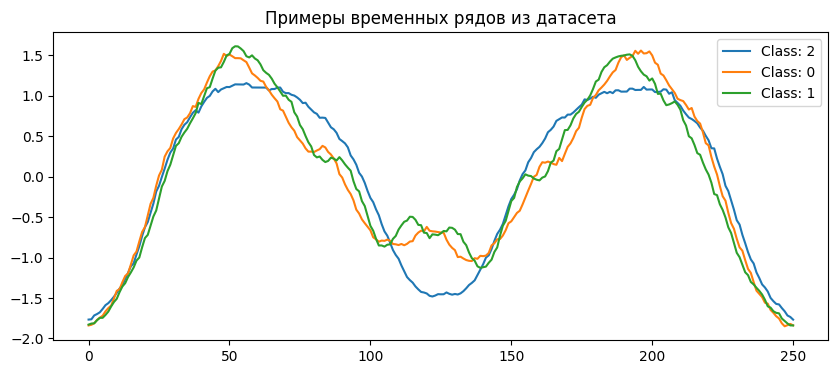

In [2]:
# Загрузка и подготовка данных
from sktime.datasets import load_arrow_head
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Мы используем датасет ArrowHead (форма наконечников стрел) или любой другой из UCR
X, y = load_arrow_head(return_type="numpy3d")
# X имеет форму (Кол-во образцов, кол-во каналов=1, длина ряда)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# Отрисовка пары примеров временных рядов разных классов
plt.figure(figsize=(10, 4))
for i in range(3):
    plt.plot(X_train[i, 0, :], label=f"Class: {y_train[i]}")
plt.title("Примеры временных рядов из датасета")
plt.legend()
plt.show()

### Задание 2.1: Классификация с помощью алгоритма ROCKET (Shapelets/Convolutions)

Используйте класс `RocketClassifier` из библиотеки `sktime`. Этот алгоритм генерирует случайные свертки для извлечения признаков и использует Ridge Regression для классификации.

**Задание:**
1. Подключите `RocketClassifier` из `sktime.classification.kernel_based`. Обучите его на `X_train`, `y_train`.
2. Предскажите классы для `X_test` и посчитайте `accuracy_score`. Замерьте время обучения.

In [3]:
!pip install numba


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numba

In [5]:
%%time
from sktime.classification.kernel_based import RocketClassifier
import time

# Ваш код здесь...
rocket_classifier = RocketClassifier()
rocket_classifier.fit(X_train, y_train)

preds = rocket_classifier.predict(X_test)

accuracy_score(y_test, preds)

CPU times: total: 43.3 s
Wall time: 43.4 s


0.9375

### Задание № 2.2: Использование алгоритма на основе словарей (Dictionary-based: cBOSS / WEASEL)

Теперь протестируйте класс `BOSSEnsemble` или `ContractableBOSS` из библиотеки `sktime` (раздел `dictionary_based`).
Эти методы преобразуют временные ряды в дискретные слова (алфавит) с использованием скользящего окна (SFA), и оценивают частость.

**Задание:**
1. Подключите любую модель BOSS-семейства.
2. Проведите обучение и вычислите метрику `accuracy_score`. Сравните время обучения с ROCKET.

In [6]:
%%time
from sktime.classification.dictionary_based import ContractableBOSS

# Ваш код здесь...
cboss = ContractableBOSS()
cboss.fit(X_train, y_train)

preds = cboss.predict(X_test)

accuracy_score(y_test, preds)

CPU times: total: 1min 36s
Wall time: 1min 37s


0.96875

cBOSS отработал чуть дольше и дал чуть лучший показатель точности.

### Задание №2.3: Глубокая архитектура для временных рядов (1D-CNN) (с помощью PyTorch)

Создайте простую свёрточную сеть с использованием 1D свёрток. Нейросети для 1D рядов похожи на 2D-сети (картинки), но срез окна проходит вдоль временной оси. Суть использования CNN-архитектур - извлечение сложных локальных и глобальных признаков (features) из формы временного ряда.

**Задание:**
1. Подготовьте данные для фреймворка (PyTorch). 
2. Напишите 2-3 слоя `Conv1D` + `ReLU` + `MaxPooling1D`, затем `Flatten` и выходной слой `Dense` c функцией Softmax.
3. Обучите модель в течение небольшого количества эпох, подсчитайте `accuracy` на тестовом наборе. Сравните с классическими методами (Rocket, BOSS).

In [7]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import time
import matplotlib.pyplot as plt

In [8]:
# 1. Построение простой архитектуры 1D-CNN
class Simple1DCNN(nn.Module):
    def __init__(self, num_classes):
        super(Simple1DCNN, self).__init__()
        # Входной канал = 1 (так как у нас одномерный временной ряд)
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=2)
        
        self.flatten = nn.Flatten()
        
        # Вычисляем размер после сверток и пулинга (для ArrowHead с длиной 251)
        # После conv1: 251 - 3 + 1 = 249. pool1: 249 // 2 = 124
        # После conv2: 124 - 3 + 1 = 122. pool2: 122 // 2 = 61
        # Итого: 64 канала * 61 = 3904
        self.fc1 = nn.Linear(64 * 61, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

In [9]:
cnn = Simple1DCNN(len(np.unique(y_train)))
len(np.unique(y_train))

3

In [10]:
# ваш код здесь
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.LongTensor(y_train.astype(float))
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.LongTensor(y_test.astype(float))

In [11]:
train_ds = TensorDataset(X_train_t, y_train_t)
test_ds = TensorDataset(X_test_t, y_test_t)

In [12]:
train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False
)

In [13]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn.parameters())

In [14]:
def train(model, loader, optimizer, loss_fn):
    model.train()
    for X, y in loader:
        optimizer.zero_grad()

        logits = model(X)
        loss = loss_fn(logits, y)

        loss.backward()
        optimizer.step()

In [15]:
def test(model, loader):
    correct = 0
    num = 0

    model.eval()
    with torch.no_grad():
        for X, y in loader:
            logits = model(X)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == y).sum()
            num += len(X)

    return correct / num

In [16]:
%%time
epochs = 100
accuracies = []

for epoch in range(1, epochs + 1):
    print('-' * 10)
    print(f'Epoch {epoch}')
    train(cnn, train_loader, optimizer, loss_fn)
    accuracy = test(cnn, test_loader)
    accuracies.append(accuracy)
    print(f'Accuracy {accuracy}')

----------
Epoch 1
Accuracy 0.5625
----------
Epoch 2
Accuracy 0.625
----------
Epoch 3
Accuracy 0.671875
----------
Epoch 4
Accuracy 0.71875
----------
Epoch 5
Accuracy 0.609375
----------
Epoch 6
Accuracy 0.734375
----------
Epoch 7
Accuracy 0.765625
----------
Epoch 8
Accuracy 0.75
----------
Epoch 9
Accuracy 0.765625
----------
Epoch 10
Accuracy 0.71875
----------
Epoch 11
Accuracy 0.796875
----------
Epoch 12
Accuracy 0.765625
----------
Epoch 13
Accuracy 0.78125
----------
Epoch 14
Accuracy 0.734375
----------
Epoch 15
Accuracy 0.765625
----------
Epoch 16
Accuracy 0.765625
----------
Epoch 17
Accuracy 0.78125
----------
Epoch 18
Accuracy 0.796875
----------
Epoch 19
Accuracy 0.859375
----------
Epoch 20
Accuracy 0.78125
----------
Epoch 21
Accuracy 0.828125
----------
Epoch 22
Accuracy 0.8125
----------
Epoch 23
Accuracy 0.8125
----------
Epoch 24
Accuracy 0.8125
----------
Epoch 25
Accuracy 0.828125
----------
Epoch 26
Accuracy 0.84375
----------
Epoch 27
Accuracy 0.875
-------

Text(0, 0.5, 'Accuracy')

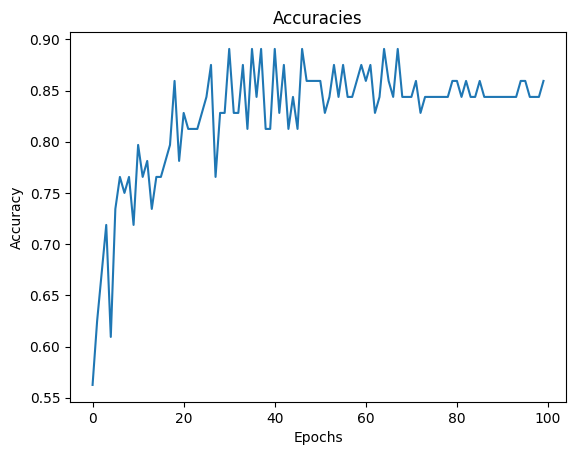

In [17]:
plt.plot(accuracies)
plt.title('Accuracies')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

Accuracy получилось меньше, но зато время обучения значительно сократилось.